In [2]:
import pandas as pd

file_path = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [3]:
print("Number of columns:", len(df.columns))
print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of columns: 53

Column names:
1. Type
2. Days for shipping (real)
3. Days for shipment (scheduled)
4. Benefit per order
5. Sales per customer
6. Delivery Status
7. Late_delivery_risk
8. Category Id
9. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image


In [4]:
print("Total rows:", len(df))
print("Unique Order IDs:", df["Order Id"].nunique())
print("Unique Order Item IDs:", df["Order Item Id"].nunique())

print("\nRows per Order:")
print(df.groupby("Order Id").size().describe())

Total rows: 180519
Unique Order IDs: 65752
Unique Order Item IDs: 180519

Rows per Order:
count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
dtype: float64


In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nTotal missing values:", df.isnull().sum().sum())

Columns with missing values:
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

Total missing values: 336209


In [6]:
# Check completely duplicated rows
total_duplicates = df.duplicated().sum()

# Check duplicate Order Item IDs
duplicate_item_ids = df["Order Item Id"].duplicated().sum()

print("Completely duplicated rows:", total_duplicates)
print("Duplicate Order Item IDs:", duplicate_item_ids)

Completely duplicated rows: 0
Duplicate Order Item IDs: 0


In [7]:
print(df.dtypes)

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

In [8]:
# Convert date columns from text to datetime
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"],
    errors="coerce"
)

print("Date columns converted successfully!")

print("\nOrder date range:")
print(df["order date (DateOrders)"].min())
print("to")
print(df["order date (DateOrders)"].max())

print("\nShipping date range:")
print(df["shipping date (DateOrders)"].min())
print("to")
print(df["shipping date (DateOrders)"].max())

Date columns converted successfully!

Order date range:
2015-01-01 00:00:00
to
2018-01-31 23:38:00

Shipping date range:
2015-01-03 00:00:00
to
2018-02-06 22:14:00


In [9]:
print("Missing order dates:",
      df["order date (DateOrders)"].isna().sum())

print("Missing shipping dates:",
      df["shipping date (DateOrders)"].isna().sum())

Missing order dates: 0
Missing shipping dates: 0


In [10]:
# Create useful date features

df["Order Year"] = df["order date (DateOrders)"].dt.year
df["Order Month"] = df["order date (DateOrders)"].dt.month
df["Order Month Name"] = df["order date (DateOrders)"].dt.month_name()
df["Order Quarter"] = df["order date (DateOrders)"].dt.quarter
df["Order Day"] = df["order date (DateOrders)"].dt.day
df["Order Day Name"] = df["order date (DateOrders)"].dt.day_name()

print("Date features created successfully!")

print("\nNew date features:")
print(df[[
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Day",
    "Order Day Name"
]].head())

Date features created successfully!

New date features:
   Order Year  Order Month Order Month Name  Order Quarter  Order Day  \
0        2018            1          January              1         31   
1        2018            1          January              1         13   
2        2018            1          January              1         13   
3        2018            1          January              1         13   
4        2018            1          January              1         13   

  Order Day Name  
0      Wednesday  
1       Saturday  
2       Saturday  
3       Saturday  
4       Saturday  


In [10]:
# Create useful date features

df["Order Year"] = df["order date (DateOrders)"].dt.year
df["Order Month"] = df["order date (DateOrders)"].dt.month
df["Order Month Name"] = df["order date (DateOrders)"].dt.month_name()
df["Order Quarter"] = df["order date (DateOrders)"].dt.quarter
df["Order Day"] = df["order date (DateOrders)"].dt.day
df["Order Day Name"] = df["order date (DateOrders)"].dt.day_name()

print("Date features created successfully!")

print("\nNew date features:")
print(df[[
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Day",
    "Order Day Name"
]].head())

Date features created successfully!

New date features:
   Order Year  Order Month Order Month Name  Order Quarter  Order Day  \
0        2018            1          January              1         31   
1        2018            1          January              1         13   
2        2018            1          January              1         13   
3        2018            1          January              1         13   
4        2018            1          January              1         13   

  Order Day Name  
0      Wednesday  
1       Saturday  
2       Saturday  
3       Saturday  
4       Saturday  


In [10]:
# Create useful date features

df["Order Year"] = df["order date (DateOrders)"].dt.year
df["Order Month"] = df["order date (DateOrders)"].dt.month
df["Order Month Name"] = df["order date (DateOrders)"].dt.month_name()
df["Order Quarter"] = df["order date (DateOrders)"].dt.quarter
df["Order Day"] = df["order date (DateOrders)"].dt.day
df["Order Day Name"] = df["order date (DateOrders)"].dt.day_name()

print("Date features created successfully!")

print("\nNew date features:")
print(df[[
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Day",
    "Order Day Name"
]].head())

Date features created successfully!

New date features:
   Order Year  Order Month Order Month Name  Order Quarter  Order Day  \
0        2018            1          January              1         31   
1        2018            1          January              1         13   
2        2018            1          January              1         13   
3        2018            1          January              1         13   
4        2018            1          January              1         13   

  Order Day Name  
0      Wednesday  
1       Saturday  
2       Saturday  
3       Saturday  
4       Saturday  


In [11]:
# Calculate basic business KPIs

total_orders = df["Order Id"].nunique()
total_order_items = df["Order Item Id"].nunique()
total_sales = df["Sales"].sum()
total_quantity = df["Order Item Quantity"].sum()
total_profit = df["Order Profit Per Order"].sum()

late_delivery_rate = df["Late_delivery_risk"].mean() * 100

print("===== SUPPLY CHAIN KPIs =====")
print(f"Total Orders: {total_orders:,}")
print(f"Total Order Items: {total_order_items:,}")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")

===== SUPPLY CHAIN KPIs =====
Total Orders: 65,752
Total Order Items: 180,519
Total Sales: $36,784,735.01
Total Quantity Sold: 384,079
Total Profit: $3,966,902.97
Late Delivery Rate: 54.83%


In [12]:
# Delivery performance analysis

avg_actual_shipping = df["Days for shipping (real)"].mean()
avg_scheduled_shipping = df["Days for shipment (scheduled)"].mean()

late_orders = df[df["Late_delivery_risk"] == 1]

print("===== DELIVERY PERFORMANCE =====")
print(f"Average actual shipping days: {avg_actual_shipping:.2f}")
print(f"Average scheduled shipping days: {avg_scheduled_shipping:.2f}")
print(f"Late-delivery records: {len(late_orders):,}")
print(f"Late-delivery percentage: {len(late_orders) / len(df) * 100:.2f}%")

===== DELIVERY PERFORMANCE =====
Average actual shipping days: 3.50
Average scheduled shipping days: 2.93
Late-delivery records: 98,977
Late-delivery percentage: 54.83%


In [13]:
# Analyze delivery performance by shipping mode

shipping_analysis = df.groupby("Shipping Mode").agg(
    Total_Orders=("Order Id", "nunique"),
    Total_Order_Items=("Order Item Id", "count"),
    Late_Delivery_Rate=("Late_delivery_risk", "mean"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

shipping_analysis["Late_Delivery_Rate"] = (
    shipping_analysis["Late_Delivery_Rate"] * 100
)

shipping_analysis["Shipping_Delay"] = (
    shipping_analysis["Avg_Actual_Shipping"]
    - shipping_analysis["Avg_Scheduled_Shipping"]
)

shipping_analysis = shipping_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print(shipping_analysis.to_string(index=False))

 Shipping Mode  Total_Orders  Total_Order_Items  Late_Delivery_Rate  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Shipping_Delay
   First Class         10079              27814           95.322499             2.000000                     1.0        1.000000
  Second Class         12778              35216           76.632781             3.990828                     2.0        1.990828
      Same Day          3571               9737           45.743042             0.478279                     0.0        0.478279
Standard Class         39324             107752           38.071683             3.995907                     4.0       -0.004093


In [14]:
# Analyze delivery status

delivery_status = df.groupby("Delivery Status").agg(
    Order_Items=("Order Item Id", "count"),
    Unique_Orders=("Order Id", "nunique"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

delivery_status["Percentage"] = (
    delivery_status["Order_Items"] / len(df) * 100
)

print(delivery_status.to_string(index=False))

  Delivery Status  Order_Items  Unique_Orders  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Percentage
 Advance shipping        41592          15127             2.498149                4.000000   23.040234
    Late delivery        98977          36048             4.089253                2.471069   54.829132
Shipping canceled         7754           2855             3.476657                2.903921    4.295393
 Shipping on time        32196          11722             2.975214                2.975214   17.835242


In [15]:
# Analyze sales and profit by product category

category_analysis = df.groupby("Category Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

category_analysis["Profit_Margin"] = (
    category_analysis["Total_Profit"]
    / category_analysis["Total_Sales"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

print(category_analysis.to_string(index=False))

       Category Name  Total_Sales  Total_Profit  Quantity_Sold  Order_Items  Profit_Margin
             Fishing 6.929654e+06 756220.767190          17325        17325      10.912822
              Cleats 4.431943e+06 494636.919791          73734        24551      11.160724
    Camping & Hiking 4.118426e+06 427455.568106          13729        13729      10.379101
    Cardio Equipment 3.694843e+06 383011.098485          37587        12487      10.366099
     Women's Apparel 3.147800e+06 350421.029567          62956        21035      11.132252
        Water Sports 3.113845e+06 325146.960038          15540        15540      10.441977
      Men's Footwear 2.891758e+06 311902.820214          22246        22246      10.785925
Indoor/Outdoor Games 2.888994e+06 318451.430554          57803        19298      11.022918
       Shop By Sport 1.309522e+06 129813.960315          32726        10984       9.913079
           Computers 6.630000e+05  69656.810171            442          442      10.506306

In [16]:
# Top 10 products by sales

product_analysis = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

product_analysis["Profit_Margin"] = (
    product_analysis["Total_Profit"]
    / product_analysis["Total_Sales"]
    * 100
)

top_10_products = product_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 PRODUCTS BY SALES =====")
print(top_10_products.to_string(index=False))

===== TOP 10 PRODUCTS BY SALES =====
                                 Product Name  Total_Sales  Total_Profit  Quantity_Sold  Order_Items  Profit_Margin
    Field & Stream Sportsman 16 Gun Fire Safe 6.929654e+06 756220.767190          17325        17325      10.912822
             Perfect Fitness Perfect Rip Deck 4.421143e+06 493828.299782          73698        24515      11.169697
Diamondback Women's Serene Classic Comfort Bi 4.118426e+06 427455.568106          13729        13729      10.379101
            Nike Men's Free 5.0+ Running Shoe 3.667633e+06 379915.818503          36680        12169      10.358610
         Nike Men's Dri-FIT Victory Golf Polo 3.147800e+06 350421.029567          62956        21035      11.132252
                  Pelican Sunstream 100 Kayak 3.099845e+06 324076.370020          15500        15500      10.454599
      Nike Men's CJ Elite 2 TD Football Cleat 2.891758e+06 311902.820214          22246        22246      10.785925
             O'Brien Men's Neoprene

In [17]:
# Monthly sales trend

monthly_sales = (
    df.groupby(
        df["order date (DateOrders)"].dt.to_period("M")
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["order date (DateOrders)"] = (
    monthly_sales["order date (DateOrders)"]
    .astype(str)
)

print("===== MONTHLY SALES =====")
print(monthly_sales.to_string(index=False))

===== MONTHLY SALES =====
order date (DateOrders)        Sales
                2015-01 1.051590e+06
                2015-02 9.270099e+05
                2015-03 1.051254e+06
                2015-04 1.014463e+06
                2015-05 1.050478e+06
                2015-06 1.024006e+06
                2015-07 1.038081e+06
                2015-08 1.029495e+06
                2015-09 1.018339e+06
                2015-10 1.049154e+06
                2015-11 1.029120e+06
                2015-12 1.057841e+06
                2016-01 1.046308e+06
                2016-02 9.685428e+05
                2016-03 1.025853e+06
                2016-04 1.001212e+06
                2016-05 1.029400e+06
                2016-06 1.003060e+06
                2016-07 1.045716e+06
                2016-08 1.048200e+06
                2016-09 1.002397e+06
                2016-10 1.048131e+06
                2016-11 1.047590e+06
                2016-12 1.037408e+06
                2017-01 1.029698e+06
            

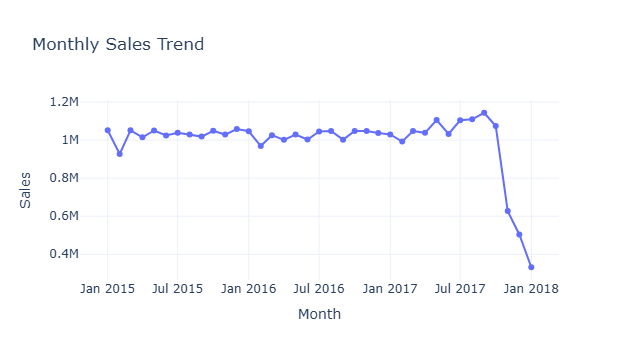

In [18]:
import plotly.express as px

fig = px.line(
    monthly_sales,
    x="order date (DateOrders)",
    y="Sales",
    title="Monthly Sales Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Sales",
    template="plotly_white"
)

fig.show()

In [19]:
# Yearly sales analysis

yearly_sales = df.groupby("Order Year").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

print("===== YEARLY SALES ANALYSIS =====")
print(yearly_sales.to_string(index=False))

===== YEARLY SALES ANALYSIS =====
 Order Year  Total_Sales  Total_Profit  Quantity_Sold  Order_Items
       2015 1.234083e+07  1.318857e+06         138480        62650
       2016 1.230382e+07  1.310119e+06         137352        62550
       2017 1.180844e+07  1.304085e+06         106124        53196
       2018 3.316501e+05  3.384189e+04           2123         2123


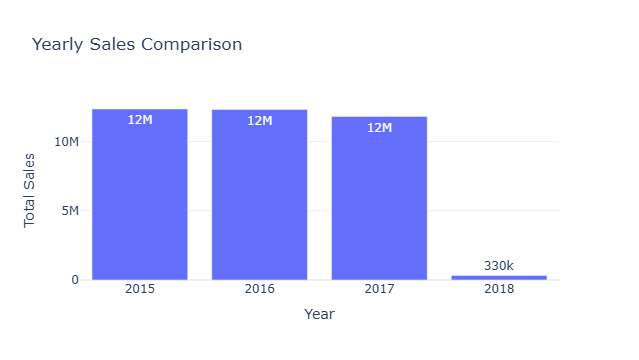

In [21]:
import plotly.express as px

fig = px.bar(
    yearly_sales,
    x="Order Year",
    y="Total_Sales",
    title="Yearly Sales Comparison",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Sales",
    template="plotly_white"
)

fig.show()

In [22]:
# Sales and profit by market

market_analysis = df.groupby("Market").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

market_analysis["Profit_Margin"] = (
    market_analysis["Total_Profit"]
    / market_analysis["Total_Sales"]
    * 100
)

market_analysis = market_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES BY MARKET =====")
print(market_analysis.to_string(index=False))

===== SALES BY MARKET =====
      Market  Total_Sales  Total_Profit  Quantity_Sold  Order_Items  Profit_Margin
      Europe 1.087240e+07  1.169443e+06         105238        50252      10.756073
       LATAM 1.027761e+07  1.123322e+06         112942        51594      10.929791
Pacific Asia 8.273744e+06  8.577534e+05          83680        41260      10.367174
        USCA 5.066529e+06  5.643138e+05          56616        25799      11.138075
      Africa 2.294453e+06  2.520712e+05          25603        11614      10.986113


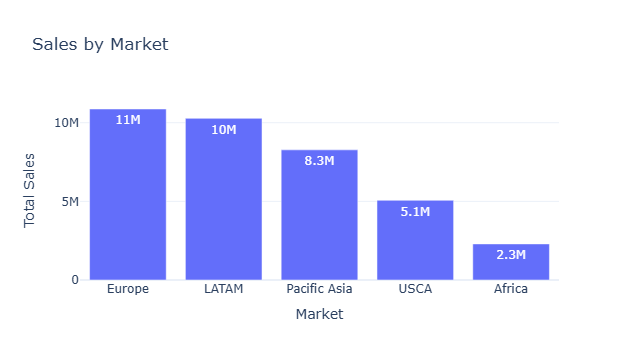

In [23]:
# Market sales visualization

fig = px.bar(
    market_analysis,
    x="Market",
    y="Total_Sales",
    title="Sales by Market",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Total Sales",
    template="plotly_white"
)

fig.show()

In [24]:
# Delivery performance by shipping mode

shipping_analysis = df.groupby("Shipping Mode").agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

shipping_analysis["Late_Delivery_Rate"] = (
    shipping_analysis["Late_Deliveries"]
    / shipping_analysis["Total_Order_Items"]
    * 100
)

shipping_analysis["Shipping_Delay"] = (
    shipping_analysis["Avg_Actual_Shipping"]
    - shipping_analysis["Avg_Scheduled_Shipping"]
)

shipping_analysis = shipping_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print("===== DELIVERY PERFORMANCE BY SHIPPING MODE =====")
print(shipping_analysis.to_string(index=False))

===== DELIVERY PERFORMANCE BY SHIPPING MODE =====
 Shipping Mode  Total_Order_Items  Late_Deliveries  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Late_Delivery_Rate  Shipping_Delay
   First Class              27814            26513             2.000000                     1.0           95.322499        1.000000
  Second Class              35216            26987             3.990828                     2.0           76.632781        1.990828
      Same Day               9737             4454             0.478279                     0.0           45.743042        0.478279
Standard Class             107752            41023             3.995907                     4.0           38.071683       -0.004093


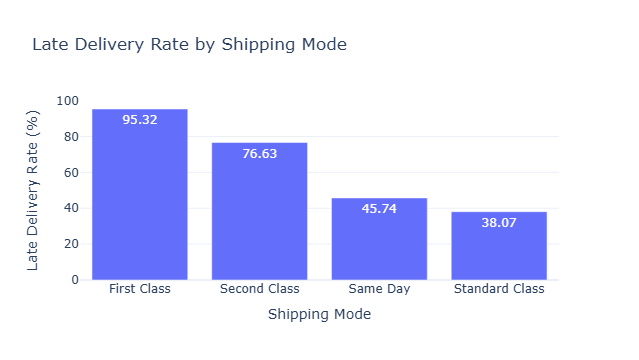

In [25]:
# Late delivery rate by shipping mode

fig = px.bar(
    shipping_analysis,
    x="Shipping Mode",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Shipping Mode",
    text_auto=".2f"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white"
)

fig.show()

In [26]:
# Delivery performance by region

region_delivery = df.groupby("Order Region").agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

region_delivery["Late_Delivery_Rate"] = (
    region_delivery["Late_Deliveries"]
    / region_delivery["Total_Order_Items"]
    * 100
)

region_delivery["Shipping_Delay"] = (
    region_delivery["Avg_Actual_Shipping"]
    - region_delivery["Avg_Scheduled_Shipping"]
)

region_delivery = region_delivery.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print("===== DELIVERY PERFORMANCE BY REGION =====")
print(region_delivery.to_string(index=False))

===== DELIVERY PERFORMANCE BY REGION =====
   Order Region  Total_Order_Items  Late_Deliveries  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Late_Delivery_Rate  Shipping_Delay
 Central Africa               1677              972             3.560525                2.920692           57.960644        0.639833
     South Asia               7731             4350             3.502005                2.904540           56.266977        0.597465
    East Africa               1852             1036             3.514579                2.943844           55.939525        0.570734
 Western Europe              27109            15140             3.498432                2.901029           55.848611        0.597403
 South of  USA                4045             2256             3.492707                2.912732           55.772559        0.579975
 Eastern Europe               3920             2182             3.500765                2.920918           55.663265        0.579847
    East of USA           

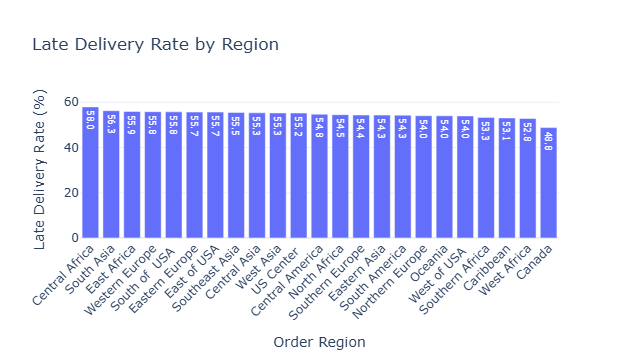

In [27]:
# Regional late delivery rate visualization

fig = px.bar(
    region_delivery,
    x="Order Region",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Region",
    text_auto=".1f"
)

fig.update_layout(
    xaxis_title="Order Region",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

In [28]:
# Top 10 cities by sales

city_sales = df.groupby("Order City").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

city_sales = city_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 CITIES BY SALES =====")
print(city_sales.to_string(index=False))

===== TOP 10 CITIES BY SALES =====
   Order City   Total_Sales  Total_Profit  Quantity_Sold  Order_Items
New York City 436061.538159  47889.759868           4877         2202
Santo Domingo 432351.878303  51111.670019           4899         2211
  Los Angeles 370545.137497  38014.360024           4068         1845
  Tegucigalpa 364129.987113  40973.640056           3913         1783
      Managua 335424.756486  34319.950107           3809         1682
  Mexico City 298471.835883  33523.450009           3258         1484
       Manila 271819.805030  31194.520013           2767         1381
San Francisco 256245.625345  23243.620261           2753         1297
 Philadelphia 255914.244948  26661.430046           2880         1302
       London 255151.244618  33458.630002           2482         1187


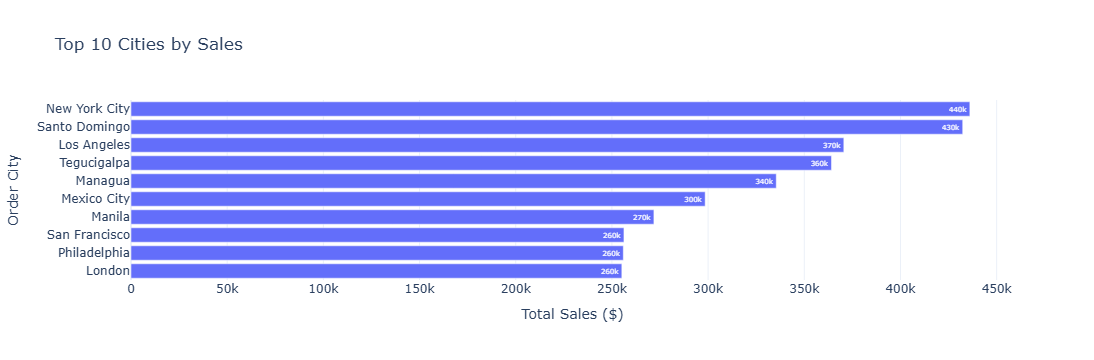

In [29]:
# Top 10 cities by sales visualization

fig = px.bar(
    city_sales.sort_values("Total_Sales"),
    x="Total_Sales",
    y="Order City",
    orientation="h",
    title="Top 10 Cities by Sales",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Total Sales ($)",
    yaxis_title="Order City",
    template="plotly_white"
)

fig.show()

In [30]:
# Sales performance by customer segment

segment_sales = df.groupby("Customer Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

segment_sales["Profit_Margin"] = (
    segment_sales["Total_Profit"]
    / segment_sales["Total_Sales"]
    * 100
)

segment_sales = segment_sales.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES BY CUSTOMER SEGMENT =====")
print(segment_sales.to_string(index=False))

===== SALES BY CUSTOMER SEGMENT =====
Customer Segment  Total_Sales  Total_Profit  Quantity_Sold  Order_Items  Profit_Margin
        Consumer 1.909579e+07  2.073488e+06         199234        93504      10.858350
       Corporate 1.116841e+07  1.202575e+06         116560        54789      10.767650
     Home Office 6.520538e+06  6.908403e+05          68285        32226      10.594836


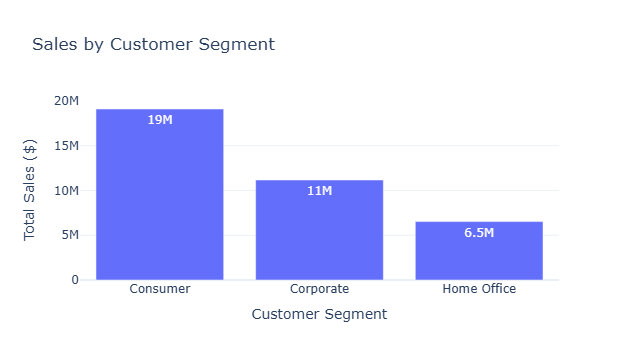

In [31]:
# Customer segment sales visualization

fig = px.bar(
    segment_sales,
    x="Customer Segment",
    y="Total_Sales",
    title="Sales by Customer Segment",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [32]:
# Sales and profit by shipping mode

shipping_sales = df.groupby("Shipping Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

shipping_sales["Profit_Margin"] = (
    shipping_sales["Total_Profit"]
    / shipping_sales["Total_Sales"]
    * 100
)

shipping_sales = shipping_sales.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES & PROFIT BY SHIPPING MODE =====")
print(shipping_sales.to_string(index=False))

===== SALES & PROFIT BY SHIPPING MODE =====
 Shipping Mode  Total_Sales  Total_Profit  Quantity_Sold  Order_Items  Profit_Margin
Standard Class 2.202239e+07  2.370454e+06         228999       107752      10.763837
  Second Class 7.145445e+06  7.503082e+05          74862        35216      10.500510
   First Class 5.674370e+06  6.431219e+05          59286        27814      11.333804
      Same Day 1.942529e+06  2.030184e+05          20932         9737      10.451246


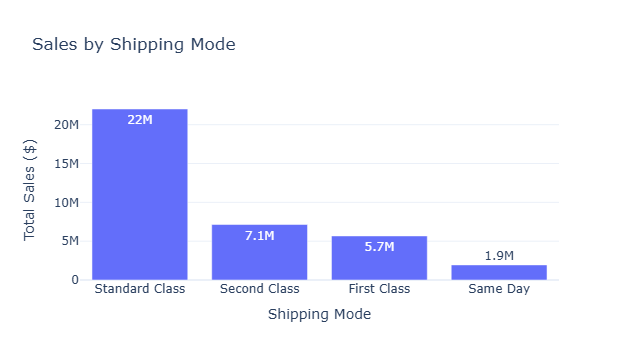

In [33]:
# Sales by shipping mode visualization

fig = px.bar(
    shipping_sales,
    x="Shipping Mode",
    y="Total_Sales",
    title="Sales by Shipping Mode",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

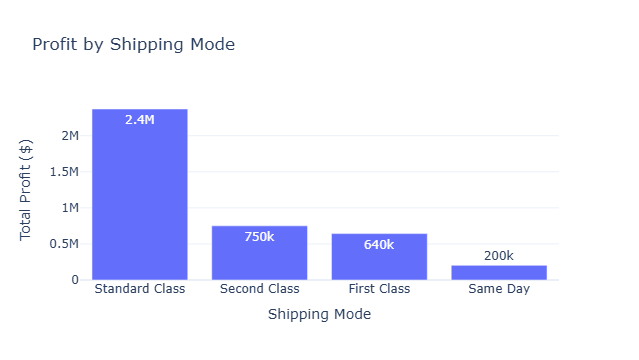

In [34]:
# Profit by shipping mode visualization

fig = px.bar(
    shipping_sales,
    x="Shipping Mode",
    y="Total_Profit",
    title="Profit by Shipping Mode",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Total Profit ($)",
    template="plotly_white"
)

fig.show()

In [35]:
# Order status analysis

order_status = df.groupby("Order Status").agg(
    Order_Items=("Order Item Id", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum")
).reset_index()

order_status = order_status.sort_values(
    "Order_Items",
    ascending=False
)

print("===== ORDER STATUS ANALYSIS =====")
print(order_status.to_string(index=False))

===== ORDER STATUS ANALYSIS =====
   Order Status  Order_Items  Total_Sales  Total_Profit
       COMPLETE        59491 1.209531e+07  1.321736e+06
PENDING_PAYMENT        39832 8.106698e+06  8.438102e+05
     PROCESSING        21902 4.504064e+06  4.948259e+05
        PENDING        20227 4.120533e+06  4.357259e+05
         CLOSED        19616 4.022624e+06  4.579811e+05
        ON_HOLD         9804 1.981543e+06  2.089130e+05
SUSPECTED_FRAUD         4062 8.259350e+05  8.513671e+04
       CANCELED         3692 7.443704e+05  7.534563e+04
 PAYMENT_REVIEW         1893 3.836537e+05  4.342879e+04


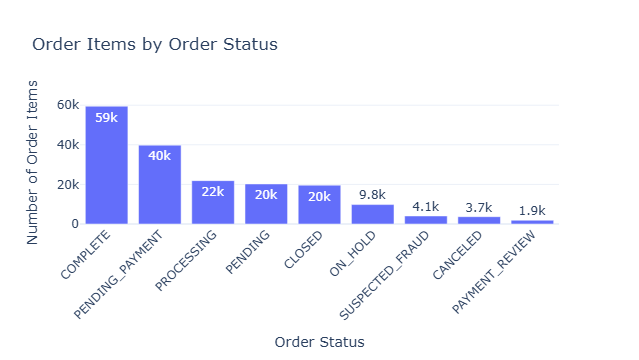

In [36]:
# Order status visualization

fig = px.bar(
    order_status,
    x="Order Status",
    y="Order_Items",
    title="Order Items by Order Status",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Order Status",
    yaxis_title="Number of Order Items",
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

In [37]:
# Late delivery analysis by customer segment

segment_delivery = df.groupby("Customer Segment").agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

segment_delivery["Late_Delivery_Rate"] = (
    segment_delivery["Late_Deliveries"]
    / segment_delivery["Total_Order_Items"]
    * 100
)

segment_delivery["Shipping_Delay"] = (
    segment_delivery["Avg_Actual_Shipping"]
    - segment_delivery["Avg_Scheduled_Shipping"]
)

segment_delivery = segment_delivery.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print("===== LATE DELIVERY BY CUSTOMER SEGMENT =====")
print(segment_delivery.to_string(index=False))

===== LATE DELIVERY BY CUSTOMER SEGMENT =====
Customer Segment  Total_Order_Items  Late_Deliveries  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Late_Delivery_Rate  Shipping_Delay
     Home Office              32226            17747             3.511450                2.933501           55.070440        0.577949
        Consumer              93504            51248             3.497508                2.932591           54.808350        0.564917
       Corporate              54789            29982             3.489788                2.929603           54.722663        0.560185


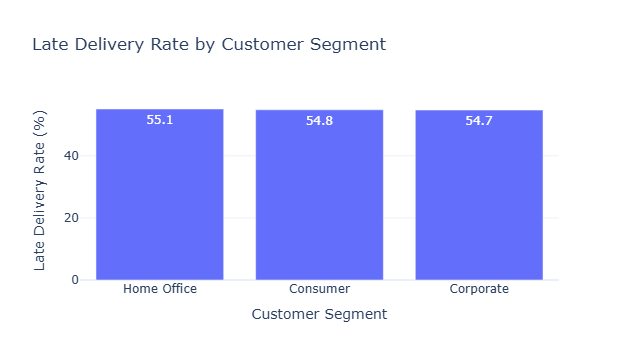

In [38]:
# Late delivery rate by customer segment

fig = px.bar(
    segment_delivery,
    x="Customer Segment",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Customer Segment",
    text_auto=".1f"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white"
)

fig.show()

In [39]:
# ===== SHIPPING DELAY ANALYSIS =====

shipping_delay = df.groupby("Shipping Mode").agg(
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

shipping_delay["Shipping_Delay"] = (
    shipping_delay["Avg_Actual_Shipping"]
    - shipping_delay["Avg_Scheduled_Shipping"]
)

print("===== SHIPPING DELAY ANALYSIS =====")
print(shipping_delay.to_string(index=False))

===== SHIPPING DELAY ANALYSIS =====
 Shipping Mode  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Shipping_Delay
   First Class             2.000000                     1.0        1.000000
      Same Day             0.478279                     0.0        0.478279
  Second Class             3.990828                     2.0        1.990828
Standard Class             3.995907                     4.0       -0.004093


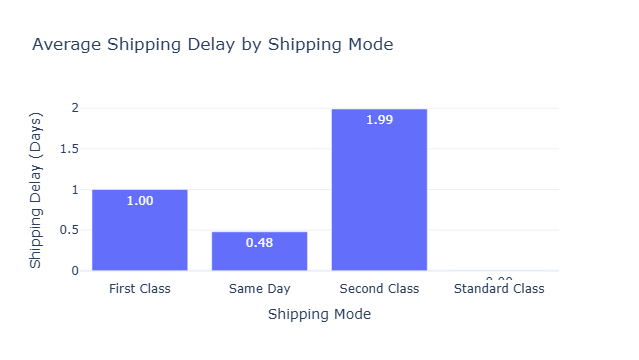

In [40]:
# ===== SHIPPING DELAY BY SHIPPING MODE =====

fig = px.bar(
    shipping_delay,
    x="Shipping Mode",
    y="Shipping_Delay",
    title="Average Shipping Delay by Shipping Mode",
    text_auto=".2f"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Shipping Delay (Days)",
    template="plotly_white"
)

fig.show()

In [41]:
# ===== DELIVERY RISK BY MARKET =====

market_delivery = df.groupby("Market").agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

market_delivery["Late_Delivery_Rate"] = (
    market_delivery["Late_Deliveries"]
    / market_delivery["Total_Order_Items"]
    * 100
)

market_delivery["Shipping_Delay"] = (
    market_delivery["Avg_Actual_Shipping"]
    - market_delivery["Avg_Scheduled_Shipping"]
)

market_delivery = market_delivery.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print("===== DELIVERY RISK BY MARKET =====")
print(market_delivery.to_string(index=False))

===== DELIVERY RISK BY MARKET =====
      Market  Total_Order_Items  Late_Deliveries  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Late_Delivery_Rate  Shipping_Delay
      Europe              50252            27743             3.487622                2.916779           55.207753        0.570843
Pacific Asia              41260            22712             3.500509                2.931144           55.046049        0.569365
        USCA              25799            14138             3.484709                2.915849           54.800574        0.568859
      Africa              11614             6340             3.511193                2.951180           54.589289        0.560014
       LATAM              51594            28044             3.508567                2.950731           54.355158        0.557836


In [2]:
# ===== LATE DELIVERY RATE BY MARKET =====

fig = px.bar(
    market_delivery,
    x="Market",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Market",
    text_auto=".1f"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white"
)

fig.show()

NameError: name 'px' is not defined

In [3]:
import plotly.express as px

In [4]:
fig = px.bar(
    market_delivery,
    x="Market",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Market",
    text_auto=".1f"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white"
)

fig.show()

NameError: name 'market_delivery' is not defined

In [5]:
# ===== RECREATE DELIVERY RISK BY MARKET =====

market_delivery = df.groupby("Market").agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

market_delivery["Late_Delivery_Rate"] = (
    market_delivery["Late_Deliveries"]
    / market_delivery["Total_Order_Items"]
    * 100
)

market_delivery["Shipping_Delay"] = (
    market_delivery["Avg_Actual_Shipping"]
    - market_delivery["Avg_Scheduled_Shipping"]
)

market_delivery = market_delivery.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print(market_delivery.to_string(index=False))

NameError: name 'df' is not defined

In [6]:
import pandas as pd

file_path = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [7]:
# ===== DELIVERY RISK BY MARKET =====

market_delivery = df.groupby("Market").agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

market_delivery["Late_Delivery_Rate"] = (
    market_delivery["Late_Deliveries"]
    / market_delivery["Total_Order_Items"]
    * 100
)

market_delivery["Shipping_Delay"] = (
    market_delivery["Avg_Actual_Shipping"]
    - market_delivery["Avg_Scheduled_Shipping"]
)

market_delivery = market_delivery.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print("===== DELIVERY RISK BY MARKET =====")
print(market_delivery.to_string(index=False))

===== DELIVERY RISK BY MARKET =====
      Market  Total_Order_Items  Late_Deliveries  Avg_Actual_Shipping  Avg_Scheduled_Shipping  Late_Delivery_Rate  Shipping_Delay
      Europe              50252            27743             3.487622                2.916779           55.207753        0.570843
Pacific Asia              41260            22712             3.500509                2.931144           55.046049        0.569365
        USCA              25799            14138             3.484709                2.915849           54.800574        0.568859
      Africa              11614             6340             3.511193                2.951180           54.589289        0.560014
       LATAM              51594            28044             3.508567                2.950731           54.355158        0.557836


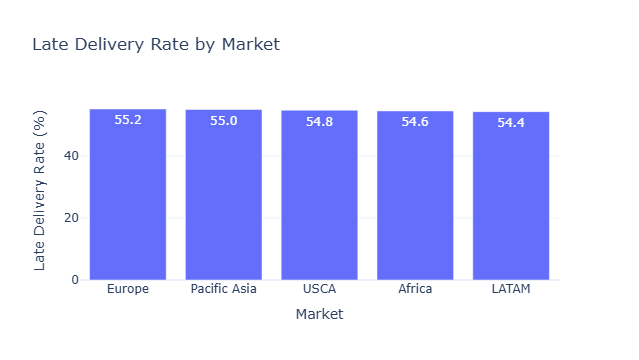

In [8]:
import plotly.express as px

fig = px.bar(
    market_delivery,
    x="Market",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Market",
    text_auto=".1f"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white"
)

fig.show()

In [9]:
# ===== SALES BY PRODUCT CATEGORY =====

category_sales = df.groupby("Category Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

category_sales = category_sales.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES BY PRODUCT CATEGORY =====")
print(category_sales.to_string(index=False))

===== SALES BY PRODUCT CATEGORY =====
       Category Name  Total_Sales  Total_Profit  Quantity_Sold  Order_Items
             Fishing 6.929654e+06 756220.767190          17325        17325
              Cleats 4.431943e+06 494636.919791          73734        24551
    Camping & Hiking 4.118426e+06 427455.568106          13729        13729
    Cardio Equipment 3.694843e+06 383011.098485          37587        12487
     Women's Apparel 3.147800e+06 350421.029567          62956        21035
        Water Sports 3.113845e+06 325146.960038          15540        15540
      Men's Footwear 2.891758e+06 311902.820214          22246        22246
Indoor/Outdoor Games 2.888994e+06 318451.430554          57803        19298
       Shop By Sport 1.309522e+06 129813.960315          32726        10984
           Computers 6.630000e+05  69656.810171            442          442
         Electronics 3.710346e+05  40891.379918           9436         3156
            Cameras  2.676077e+05  30289.799946   

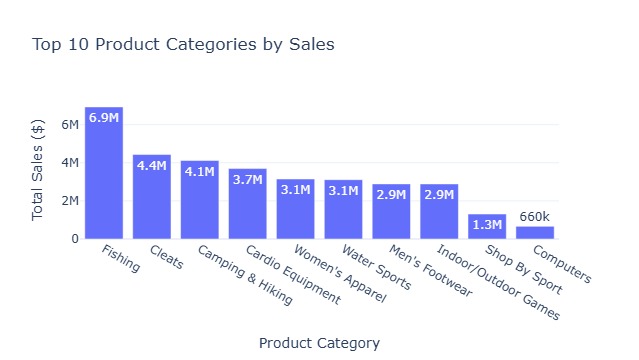

In [10]:
# ===== SALES BY PRODUCT CATEGORY CHART =====

fig = px.bar(
    category_sales.head(10),
    x="Category Name",
    y="Total_Sales",
    title="Top 10 Product Categories by Sales",
    text_auto=".2s"
)

fig.update_layout(
    xaxis_title="Product Category",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [11]:
# ===== PROFIT MARGIN BY PRODUCT CATEGORY =====

category_sales["Profit_Margin"] = (
    category_sales["Total_Profit"]
    / category_sales["Total_Sales"]
    * 100
)

category_margin = category_sales.sort_values(
    "Profit_Margin",
    ascending=False
)

print("===== PROFIT MARGIN BY PRODUCT CATEGORY =====")
print(
    category_margin[
        ["Category Name", "Total_Sales", "Total_Profit", "Profit_Margin"]
    ].to_string(index=False)
)

===== PROFIT MARGIN BY PRODUCT CATEGORY =====
       Category Name  Total_Sales  Total_Profit  Profit_Margin
   Golf Bags & Carts 1.036939e+04   1810.069992      17.455896
 Fitness Accessories 3.560144e+04   5258.390016      14.770161
                Toys 6.104660e+03    900.710000      14.754466
              Soccer 2.647705e+04   3901.949953      14.737102
    Women's Clothing 1.402830e+05  19102.849930      13.617366
 Baseball & Softball 9.405715e+04  12762.130067      13.568484
              Garden 2.577687e+05  33443.010106      12.974037
    Tennis & Racquet 4.458509e+04   5747.979996      12.892157
               Music 1.131221e+05  14436.319923      12.761715
                CDs  3.059590e+03    383.850000      12.545799
               Baby  1.222956e+04   1525.029992      12.470031
         Accessories 1.336715e+05  16643.520074      12.451060
Consumer Electronics 1.089913e+05  13223.399926      12.132530
    Men's Golf Clubs 4.703580e+04   5517.989977      11.731468
 Children

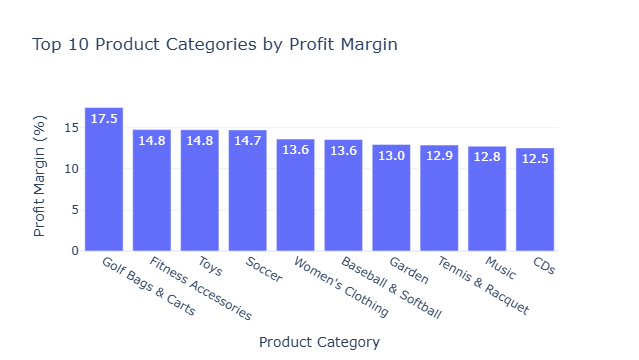

In [12]:
# ===== PROFIT MARGIN BY PRODUCT CATEGORY CHART =====

fig = px.bar(
    category_margin.head(10),
    x="Category Name",
    y="Profit_Margin",
    title="Top 10 Product Categories by Profit Margin",
    text_auto=".1f"
)

fig.update_layout(
    xaxis_title="Product Category",
    yaxis_title="Profit Margin (%)",
    template="plotly_white"
)

fig.show()

In [13]:
# ===== DISCOUNT ANALYSIS =====

discount_analysis = df.groupby("Order Item Discount Rate").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

discount_analysis = discount_analysis.sort_values(
    "Order Item Discount Rate"
)

print("===== DISCOUNT ANALYSIS =====")
print(discount_analysis.to_string(index=False))

===== DISCOUNT ANALYSIS =====
 Order Item Discount Rate  Total_Sales  Total_Profit  Order_Items
                     0.00 2.042369e+06 267412.402338        10028
                     0.01 2.042793e+06 238653.961066        10028
                     0.02 2.042818e+06 237401.160814        10028
                     0.03 2.043344e+06 222475.430184        10029
                     0.04 2.043378e+06 234683.300468        10029
                     0.05 2.043413e+06 238468.229398        10029
                     0.06 2.043421e+06 241415.970777        10029
                     0.07 2.043452e+06 233404.920995        10029
                     0.09 2.043478e+06 229769.420426        10029
                     0.10 2.043501e+06 221921.319172        10029
                     0.12 2.043578e+06 209751.549917        10029
                     0.13 2.044095e+06 214409.600314        10029
                     0.15 2.044115e+06 201177.970232        10029
                     0.16 2.044129e+06 209446.

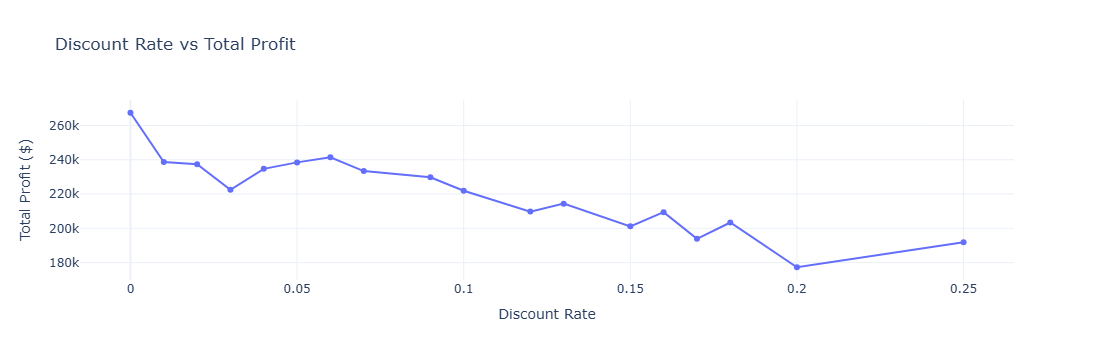

In [14]:
# ===== DISCOUNT VS PROFIT CHART =====

fig = px.line(
    discount_analysis,
    x="Order Item Discount Rate",
    y="Total_Profit",
    title="Discount Rate vs Total Profit",
    markers=True
)

fig.update_layout(
    xaxis_title="Discount Rate",
    yaxis_title="Total Profit ($)",
    template="plotly_white"
)

fig.show()

In [15]:
# ===== PROFIT MARGIN BY SHIPPING MODE =====

shipping_margin = df.groupby("Shipping Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

shipping_margin["Profit_Margin"] = (
    shipping_margin["Total_Profit"]
    / shipping_margin["Total_Sales"]
    * 100
)

shipping_margin = shipping_margin.sort_values(
    "Profit_Margin",
    ascending=False
)

print("===== PROFIT MARGIN BY SHIPPING MODE =====")
print(shipping_margin.to_string(index=False))

===== PROFIT MARGIN BY SHIPPING MODE =====
 Shipping Mode  Total_Sales  Total_Profit  Order_Items  Profit_Margin
   First Class 5.674370e+06  6.431219e+05        27814      11.333804
Standard Class 2.202239e+07  2.370454e+06       107752      10.763837
  Second Class 7.145445e+06  7.503082e+05        35216      10.500510
      Same Day 1.942529e+06  2.030184e+05         9737      10.451246


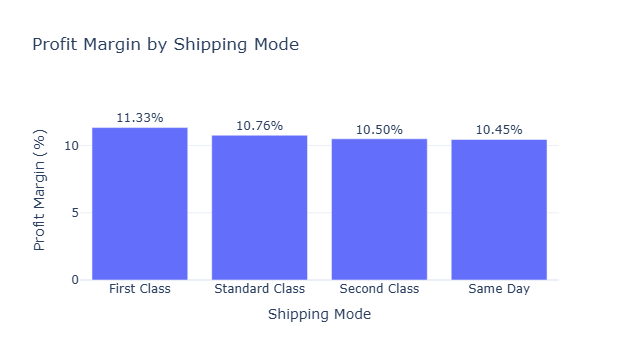

In [16]:
# ===== PROFIT MARGIN BY SHIPPING MODE CHART =====

fig = px.bar(
    shipping_margin,
    x="Shipping Mode",
    y="Profit_Margin",
    title="Profit Margin by Shipping Mode",
    text="Profit_Margin"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Profit Margin (%)",
    template="plotly_white"
)

fig.show()

In [17]:
# ===== SALES VS PROFIT BY SHIPPING MODE =====

shipping_comparison = df.groupby("Shipping Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum")
).reset_index()

print("===== SALES VS PROFIT BY SHIPPING MODE =====")
print(shipping_comparison.to_string(index=False))

===== SALES VS PROFIT BY SHIPPING MODE =====
 Shipping Mode  Total_Sales  Total_Profit
   First Class 5.674370e+06  6.431219e+05
      Same Day 1.942529e+06  2.030184e+05
  Second Class 7.145445e+06  7.503082e+05
Standard Class 2.202239e+07  2.370454e+06


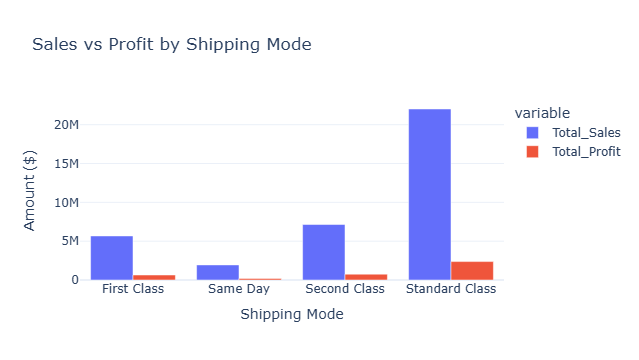

In [18]:
# ===== SALES VS PROFIT BY SHIPPING MODE CHART =====

fig = px.bar(
    shipping_comparison,
    x="Shipping Mode",
    y=["Total_Sales", "Total_Profit"],
    barmode="group",
    title="Sales vs Profit by Shipping Mode"
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Amount ($)",
    template="plotly_white"
)

fig.show()

In [19]:
# ===== SALES BY ORDER STATUS =====

status_sales = df.groupby("Order Status").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

status_sales = status_sales.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES BY ORDER STATUS =====")
print(status_sales.to_string(index=False))

===== SALES BY ORDER STATUS =====
   Order Status  Total_Sales  Total_Profit  Order_Items
       COMPLETE 1.209531e+07  1.321736e+06        59491
PENDING_PAYMENT 8.106698e+06  8.438102e+05        39832
     PROCESSING 4.504064e+06  4.948259e+05        21902
        PENDING 4.120533e+06  4.357259e+05        20227
         CLOSED 4.022624e+06  4.579811e+05        19616
        ON_HOLD 1.981543e+06  2.089130e+05         9804
SUSPECTED_FRAUD 8.259350e+05  8.513671e+04         4062
       CANCELED 7.443704e+05  7.534563e+04         3692
 PAYMENT_REVIEW 3.836537e+05  4.342879e+04         1893


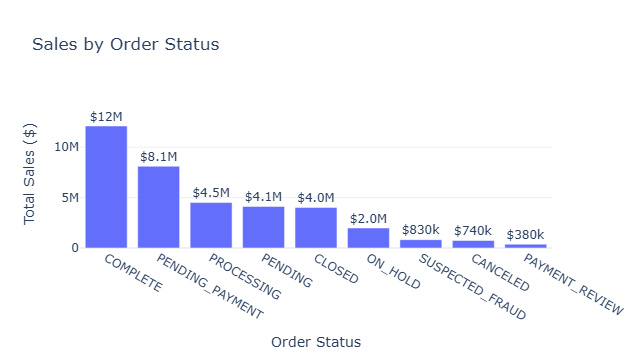

In [20]:
# ===== SALES BY ORDER STATUS CHART =====

fig = px.bar(
    status_sales,
    x="Order Status",
    y="Total_Sales",
    title="Sales by Order Status",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Status",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [21]:
# ===== PROFIT BY ORDER STATUS =====

status_profit = df.groupby("Order Status").agg(
    Total_Profit=("Order Profit Per Order", "sum"),
    Total_Sales=("Sales", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

status_profit = status_profit.sort_values(
    "Total_Profit",
    ascending=False
)

print("===== PROFIT BY ORDER STATUS =====")
print(status_profit.to_string(index=False))

===== PROFIT BY ORDER STATUS =====
   Order Status  Total_Profit  Total_Sales  Order_Items
       COMPLETE  1.321736e+06 1.209531e+07        59491
PENDING_PAYMENT  8.438102e+05 8.106698e+06        39832
     PROCESSING  4.948259e+05 4.504064e+06        21902
         CLOSED  4.579811e+05 4.022624e+06        19616
        PENDING  4.357259e+05 4.120533e+06        20227
        ON_HOLD  2.089130e+05 1.981543e+06         9804
SUSPECTED_FRAUD  8.513671e+04 8.259350e+05         4062
       CANCELED  7.534563e+04 7.443704e+05         3692
 PAYMENT_REVIEW  4.342879e+04 3.836537e+05         1893


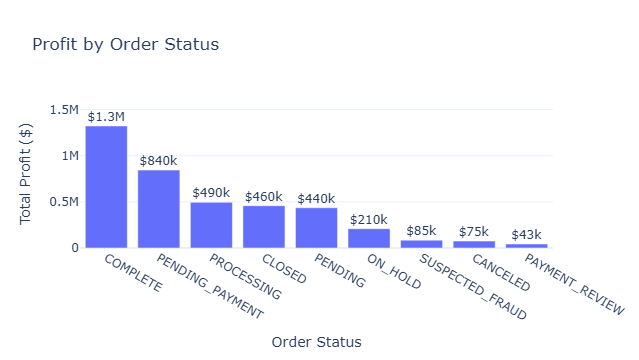

In [22]:
# ===== PROFIT BY ORDER STATUS CHART =====

fig = px.bar(
    status_profit,
    x="Order Status",
    y="Total_Profit",
    title="Profit by Order Status",
    text="Total_Profit"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Status",
    yaxis_title="Total Profit ($)",
    template="plotly_white"
)

fig.show()

In [23]:
# ===== PROFIT MARGIN BY ORDER STATUS =====

status_margin = df.groupby("Order Status").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

status_margin["Profit_Margin"] = (
    status_margin["Total_Profit"]
    / status_margin["Total_Sales"]
    * 100
)

status_margin = status_margin.sort_values(
    "Profit_Margin",
    ascending=False
)

print("===== PROFIT MARGIN BY ORDER STATUS =====")
print(status_margin.to_string(index=False))

===== PROFIT MARGIN BY ORDER STATUS =====
   Order Status  Total_Sales  Total_Profit  Order_Items  Profit_Margin
         CLOSED 4.022624e+06  4.579811e+05        19616      11.385132
 PAYMENT_REVIEW 3.836537e+05  4.342879e+04         1893      11.319790
     PROCESSING 4.504064e+06  4.948259e+05        21902      10.986209
       COMPLETE 1.209531e+07  1.321736e+06        59491      10.927667
        PENDING 4.120533e+06  4.357259e+05        20227      10.574502
        ON_HOLD 1.981543e+06  2.089130e+05         9804      10.542949
PENDING_PAYMENT 8.106698e+06  8.438102e+05        39832      10.408804
SUSPECTED_FRAUD 8.259350e+05  8.513671e+04         4062      10.307919
       CANCELED 7.443704e+05  7.534563e+04         3692      10.122062


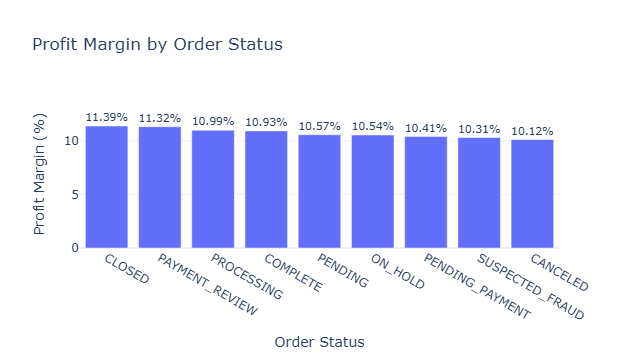

In [24]:
# ===== PROFIT MARGIN BY ORDER STATUS CHART =====

fig = px.bar(
    status_margin,
    x="Order Status",
    y="Profit_Margin",
    title="Profit Margin by Order Status",
    text="Profit_Margin"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Status",
    yaxis_title="Profit Margin (%)",
    template="plotly_white"
)

fig.show()

In [25]:
# ===== TOP 10 CUSTOMER COUNTRIES BY SALES =====

country_sales = df.groupby("Customer Country").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

country_sales = country_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 CUSTOMER COUNTRIES BY SALES =====")
print(country_sales.to_string(index=False))

===== TOP 10 CUSTOMER COUNTRIES BY SALES =====
Customer Country  Total_Sales  Total_Profit  Order_Items
         EE. UU. 2.263449e+07  2.453526e+06       111146
     Puerto Rico 1.415024e+07  1.513377e+06        69373


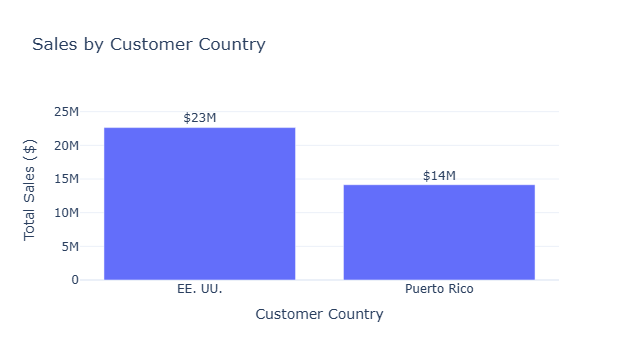

In [26]:
# ===== CUSTOMER COUNTRY SALES CHART =====

fig = px.bar(
    country_sales,
    x="Customer Country",
    y="Total_Sales",
    title="Sales by Customer Country",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Customer Country",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [27]:
# ===== TOP 10 ORDER REGIONS BY SALES =====

region_sales = df.groupby("Order Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

region_sales = region_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 ORDER REGIONS BY SALES =====")
print(region_sales.to_string(index=False))

===== TOP 10 ORDER REGIONS BY SALES =====
   Order Region  Total_Sales  Total_Profit  Order_Items
 Western Europe 5.894381e+06 625446.080548        27109
Central America 5.665712e+06 616341.570651        28341
  South America 2.960881e+06 335154.400817        14935
Northern Europe 2.155831e+06 233450.600647         9792
Southern Europe 2.047919e+06 230829.229883         9431
        Oceania 2.016654e+06 201478.020484        10148
 Southeast Asia 1.932496e+06 211342.819786         9539
      Caribbean 1.651019e+06 171825.640024         8318
   West of USA  1.571416e+06 164940.660455         7993
     South Asia 1.553681e+06 165703.900124         7731


In [1]:
# ===== ORDER REGION SALES CHART =====

fig = px.bar(
    region_sales,
    x="Order Region",
    y="Total_Sales",
    title="Top 10 Order Regions by Sales",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Region",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

NameError: name 'px' is not defined

In [2]:
import plotly.express as px

In [3]:
fig = px.bar(
    region_sales,
    x="Order Region",
    y="Total_Sales",
    title="Top 10 Order Regions by Sales",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Region",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

NameError: name 'region_sales' is not defined

In [4]:
# ===== TOP 10 ORDER REGIONS BY SALES =====

region_sales = df.groupby("Order Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

region_sales = region_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 ORDER REGIONS BY SALES =====")
print(region_sales)

NameError: name 'df' is not defined

In [5]:
import pandas as pd
import plotly.express as px

file_path = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [6]:
# ===== TOP 10 ORDER REGIONS BY SALES =====

region_sales = df.groupby("Order Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

region_sales = region_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 ORDER REGIONS BY SALES =====")
print(region_sales)

===== TOP 10 ORDER REGIONS BY SALES =====
       Order Region   Total_Sales   Total_Profit  Order_Items
22   Western Europe  5.894381e+06  625446.080548        27109
3   Central America  5.665712e+06  616341.570651        28341
12    South America  2.960881e+06  335154.400817        14935
10  Northern Europe  2.155831e+06  233450.600647         9792
17  Southern Europe  2.047919e+06  230829.229883         9431
11          Oceania  2.016654e+06  201478.020484        10148
15   Southeast Asia  1.932496e+06  211342.819786         9539
1         Caribbean  1.651019e+06  171825.640024         8318
21     West of USA   1.571416e+06  164940.660455         7993
13       South Asia  1.553681e+06  165703.900124         7731


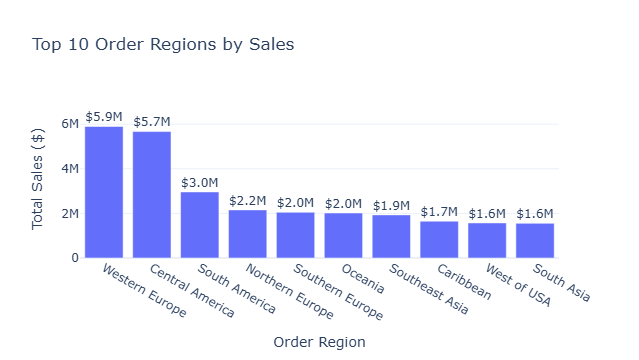

In [7]:
fig = px.bar(
    region_sales,
    x="Order Region",
    y="Total_Sales",
    title="Top 10 Order Regions by Sales",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Region",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [8]:
# ===== TOP 10 ORDER COUNTRIES BY SALES =====

country_sales = df.groupby("Order Country").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

country_sales = country_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 ORDER COUNTRIES BY SALES =====")
print(country_sales)

===== TOP 10 ORDER COUNTRIES BY SALES =====
      Order Country   Total_Sales   Total_Profit  Order_Items
48   Estados Unidos  4.879668e+06  540413.070422        24840
53          Francia  2.879942e+06  327828.580099        13222
102          México  2.633195e+06  303278.370637        13172
2          Alemania  2.074172e+06  194827.080381         9564
8         Australia  1.694622e+06  170041.580432         8497
120     Reino Unido  1.612095e+06  180942.880424         7302
20           Brasil  1.594320e+06  186713.640355         7987
31            China  1.172902e+06  122190.920525         5758
75           Italia  1.072182e+06  121545.470087         4989
69            India  9.623967e+05   99746.819972         4783


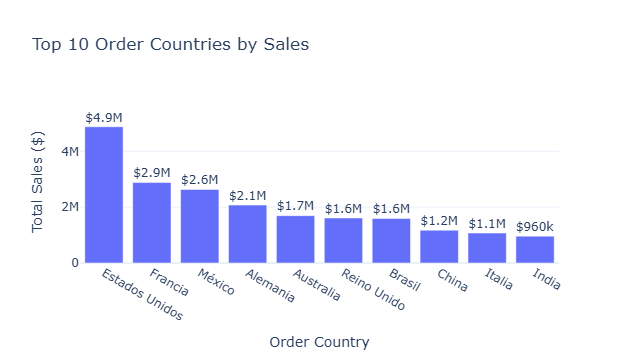

In [9]:
# ===== ORDER COUNTRY SALES CHART =====

fig = px.bar(
    country_sales,
    x="Order Country",
    y="Total_Sales",
    title="Top 10 Order Countries by Sales",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Order Country",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [10]:
# ===== SALES BY ORDER MARKET =====

order_market_sales = df.groupby("Market").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

order_market_sales = order_market_sales.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES BY ORDER MARKET =====")
print(order_market_sales)

===== SALES BY ORDER MARKET =====
         Market   Total_Sales  Total_Profit  Order_Items
1        Europe  1.087240e+07  1.169443e+06        50252
2         LATAM  1.027761e+07  1.123322e+06        51594
3  Pacific Asia  8.273744e+06  8.577534e+05        41260
4          USCA  5.066529e+06  5.643138e+05        25799
0        Africa  2.294453e+06  2.520712e+05        11614


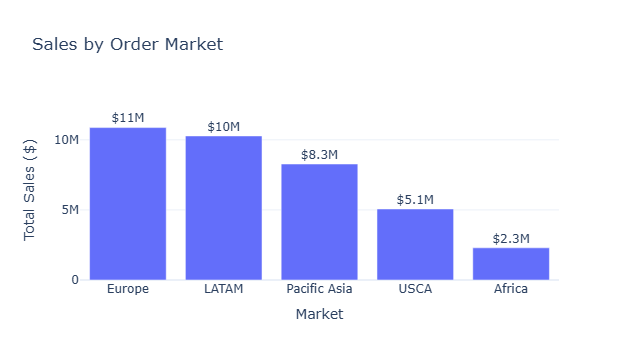

In [11]:
# ===== ORDER MARKET SALES CHART =====

fig = px.bar(
    order_market_sales,
    x="Market",
    y="Total_Sales",
    title="Sales by Order Market",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [12]:
# ===== TOP 10 PRODUCTS BY SALES =====

product_sales = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

product_sales = product_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

print("===== TOP 10 PRODUCTS BY SALES =====")
print(product_sales)

===== TOP 10 PRODUCTS BY SALES =====
                                      Product Name   Total_Sales  \
24       Field & Stream Sportsman 16 Gun Fire Safe  6.929654e+06   
71                Perfect Fitness Perfect Rip Deck  4.421143e+06   
21   Diamondback Women's Serene Classic Comfort Bi  4.118426e+06   
61               Nike Men's Free 5.0+ Running Shoe  3.667633e+06   
59            Nike Men's Dri-FIT Victory Golf Polo  3.147800e+06   
70                     Pelican Sunstream 100 Kayak  3.099845e+06   
56         Nike Men's CJ Elite 2 TD Football Cleat  2.891758e+06   
67                O'Brien Men's Neoprene Life Vest  2.888994e+06   
102  Under Armour Girls' Toddler Spine Surge Runni  1.269083e+06   
18                                     Dell Laptop  6.630000e+05   

      Total_Profit  Quantity_Sold  Order_Items  
24   756220.767190          17325        17325  
71   493828.299782          73698        24515  
21   427455.568106          13729        13729  
61   379915.818503

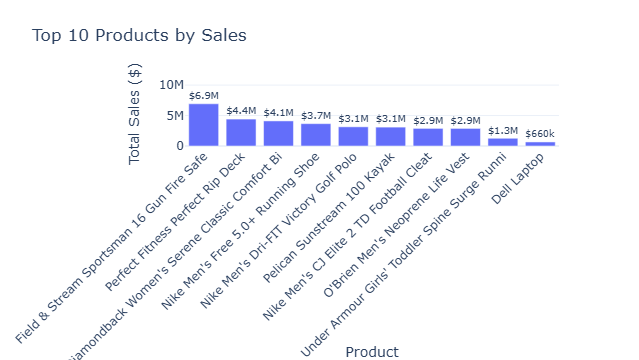

In [13]:
# ===== TOP 10 PRODUCTS SALES CHART =====

fig = px.bar(
    product_sales,
    x="Product Name",
    y="Total_Sales",
    title="Top 10 Products by Sales",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Product",
    yaxis_title="Total Sales ($)",
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

In [14]:
# ===== TOP 10 PRODUCTS BY PROFIT =====

product_profit = df.groupby("Product Name").agg(
    Total_Profit=("Order Profit Per Order", "sum"),
    Total_Sales=("Sales", "sum"),
    Quantity_Sold=("Order Item Quantity", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

product_profit = product_profit.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

print("===== TOP 10 PRODUCTS BY PROFIT =====")
print(product_profit)

===== TOP 10 PRODUCTS BY PROFIT =====
                                      Product Name   Total_Profit  \
24       Field & Stream Sportsman 16 Gun Fire Safe  756220.767190   
71                Perfect Fitness Perfect Rip Deck  493828.299782   
21   Diamondback Women's Serene Classic Comfort Bi  427455.568106   
61               Nike Men's Free 5.0+ Running Shoe  379915.818503   
59            Nike Men's Dri-FIT Victory Golf Polo  350421.029567   
70                     Pelican Sunstream 100 Kayak  324076.370020   
67                O'Brien Men's Neoprene Life Vest  318451.430554   
56         Nike Men's CJ Elite 2 TD Football Cleat  311902.820214   
102  Under Armour Girls' Toddler Spine Surge Runni  126278.510299   
18                                     Dell Laptop   69656.810171   

      Total_Sales  Quantity_Sold  Order_Items  
24   6.929654e+06          17325        17325  
71   4.421143e+06          73698        24515  
21   4.118426e+06          13729        13729  
61   3.667

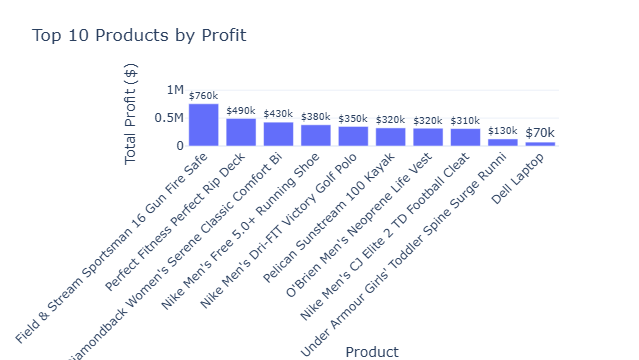

In [15]:
# ===== TOP 10 PRODUCTS PROFIT CHART =====

fig = px.bar(
    product_profit,
    x="Product Name",
    y="Total_Profit",
    title="Top 10 Products by Profit",
    text="Total_Profit"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Product",
    yaxis_title="Total Profit ($)",
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

In [16]:
# ===== SALES BY CUSTOMER SEGMENT AND MARKET =====

segment_market_sales = df.groupby(
    ["Market", "Customer Segment"]
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

segment_market_sales = segment_market_sales.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES BY CUSTOMER SEGMENT AND MARKET =====")
print(segment_market_sales)

===== SALES BY CUSTOMER SEGMENT AND MARKET =====
          Market Customer Segment   Total_Sales   Total_Profit  Order_Items
3         Europe         Consumer  5.671565e+06  627099.000311        26108
6          LATAM         Consumer  5.289639e+06  568246.210506        26598
9   Pacific Asia         Consumer  4.286861e+06  445629.430767        21284
4         Europe        Corporate  3.303071e+06  355412.120425        15313
7          LATAM        Corporate  3.139115e+06  350573.820505        15699
12          USCA         Consumer  2.660291e+06  302912.140371        13507
10  Pacific Asia        Corporate  2.515593e+06  258109.510353        12508
5         Europe      Home Office  1.897761e+06  186931.840263         8831
8          LATAM      Home Office  1.848859e+06  204501.580481         9297
13          USCA        Corporate  1.510871e+06  162718.140245         7741
11  Pacific Asia      Home Office  1.471290e+06  154014.499987         7468
0         Africa         Consumer  1.18

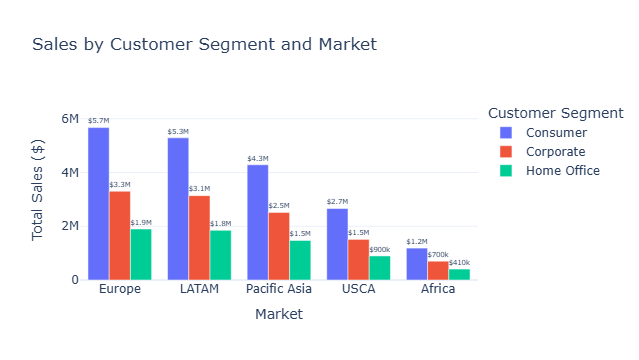

In [17]:
# ===== SALES BY CUSTOMER SEGMENT AND MARKET CHART =====

fig = px.bar(
    segment_market_sales,
    x="Market",
    y="Total_Sales",
    color="Customer Segment",
    barmode="group",
    title="Sales by Customer Segment and Market",
    text="Total_Sales"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Total Sales ($)",
    template="plotly_white"
)

fig.show()

In [18]:
# ===== PROFIT BY CUSTOMER SEGMENT AND MARKET =====

segment_market_profit = df.groupby(
    ["Market", "Customer Segment"]
).agg(
    Total_Profit=("Order Profit Per Order", "sum"),
    Total_Sales=("Sales", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

segment_market_profit = segment_market_profit.sort_values(
    "Total_Profit",
    ascending=False
)

print("===== PROFIT BY CUSTOMER SEGMENT AND MARKET =====")
print(segment_market_profit)

===== PROFIT BY CUSTOMER SEGMENT AND MARKET =====
          Market Customer Segment   Total_Profit   Total_Sales  Order_Items
3         Europe         Consumer  627099.000311  5.671565e+06        26108
6          LATAM         Consumer  568246.210506  5.289639e+06        26598
9   Pacific Asia         Consumer  445629.430767  4.286861e+06        21284
4         Europe        Corporate  355412.120425  3.303071e+06        15313
7          LATAM        Corporate  350573.820505  3.139115e+06        15699
12          USCA         Consumer  302912.140371  2.660291e+06        13507
10  Pacific Asia        Corporate  258109.510353  2.515593e+06        12508
8          LATAM      Home Office  204501.580481  1.848859e+06         9297
5         Europe      Home Office  186931.840263  1.897761e+06         8831
13          USCA        Corporate  162718.140245  1.510871e+06         7741
11  Pacific Asia      Home Office  154014.499987  1.471290e+06         7468
0         Africa         Consumer  129

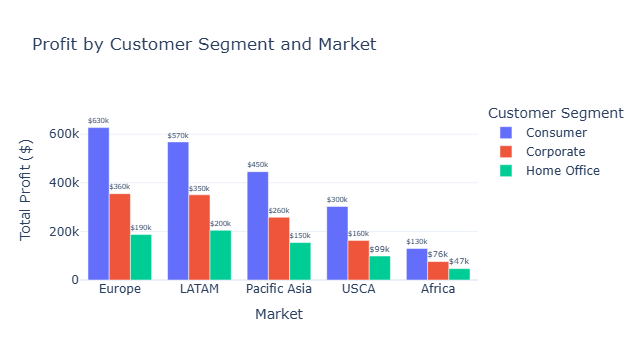

In [19]:
# ===== PROFIT BY CUSTOMER SEGMENT AND MARKET CHART =====

fig = px.bar(
    segment_market_profit,
    x="Market",
    y="Total_Profit",
    color="Customer Segment",
    barmode="group",
    title="Profit by Customer Segment and Market",
    text="Total_Profit"
)

fig.update_traces(
    texttemplate="$%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Market",
    yaxis_title="Total Profit ($)",
    template="plotly_white"
)

fig.show()

In [20]:
# ===== SALES VS PROFIT BY CUSTOMER SEGMENT =====

segment_performance = df.groupby(
    "Customer Segment"
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

segment_performance = segment_performance.sort_values(
    "Total_Sales",
    ascending=False
)

print("===== SALES VS PROFIT BY CUSTOMER SEGMENT =====")
print(segment_performance)

===== SALES VS PROFIT BY CUSTOMER SEGMENT =====
  Customer Segment   Total_Sales  Total_Profit  Order_Items
0         Consumer  1.909579e+07  2.073488e+06        93504
1        Corporate  1.116841e+07  1.202575e+06        54789
2      Home Office  6.520538e+06  6.908403e+05        32226


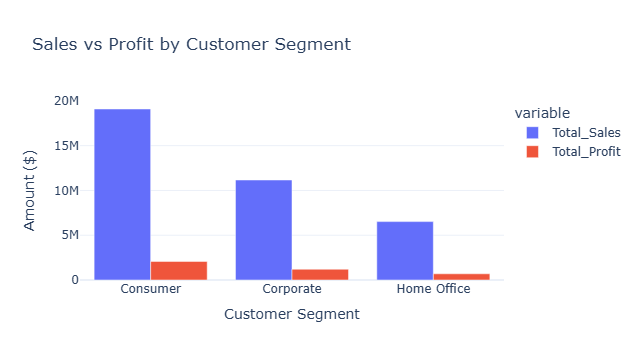

In [21]:
# ===== SALES VS PROFIT BY CUSTOMER SEGMENT CHART =====

fig = px.bar(
    segment_performance,
    x="Customer Segment",
    y=["Total_Sales", "Total_Profit"],
    barmode="group",
    title="Sales vs Profit by Customer Segment"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Amount ($)",
    template="plotly_white"
)

fig.show()

In [22]:
# ===== PROFIT MARGIN BY CUSTOMER SEGMENT =====

segment_margin = df.groupby(
    "Customer Segment"
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Order Profit Per Order", "sum"),
    Order_Items=("Order Item Id", "count")
).reset_index()

segment_margin["Profit_Margin"] = (
    segment_margin["Total_Profit"]
    / segment_margin["Total_Sales"]
    * 100
)

segment_margin = segment_margin.sort_values(
    "Profit_Margin",
    ascending=False
)

print("===== PROFIT MARGIN BY CUSTOMER SEGMENT =====")
print(segment_margin)

===== PROFIT MARGIN BY CUSTOMER SEGMENT =====
  Customer Segment   Total_Sales  Total_Profit  Order_Items  Profit_Margin
0         Consumer  1.909579e+07  2.073488e+06        93504      10.858350
1        Corporate  1.116841e+07  1.202575e+06        54789      10.767650
2      Home Office  6.520538e+06  6.908403e+05        32226      10.594836


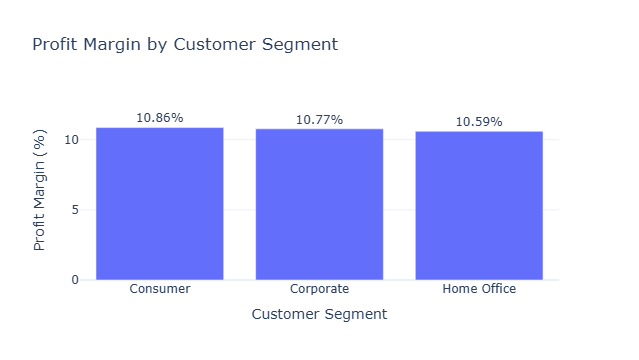

In [23]:
# ===== PROFIT MARGIN BY CUSTOMER SEGMENT CHART =====

fig = px.bar(
    segment_margin,
    x="Customer Segment",
    y="Profit_Margin",
    title="Profit Margin by Customer Segment",
    text="Profit_Margin"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Profit Margin (%)",
    template="plotly_white"
)

fig.show()

In [24]:
# ===== DELIVERY RISK BY CUSTOMER SEGMENT =====

segment_risk = df.groupby(
    "Customer Segment"
).agg(
    Total_Order_Items=("Order Item Id", "count"),
    Late_Deliveries=("Late_delivery_risk", "sum"),
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

segment_risk["Late_Delivery_Rate"] = (
    segment_risk["Late_Deliveries"]
    / segment_risk["Total_Order_Items"]
    * 100
)

segment_risk["Shipping_Delay"] = (
    segment_risk["Avg_Actual_Shipping"]
    - segment_risk["Avg_Scheduled_Shipping"]
)

segment_risk = segment_risk.sort_values(
    "Late_Delivery_Rate",
    ascending=False
)

print("===== DELIVERY RISK BY CUSTOMER SEGMENT =====")
print(segment_risk)

===== DELIVERY RISK BY CUSTOMER SEGMENT =====
  Customer Segment  Total_Order_Items  Late_Deliveries  Avg_Actual_Shipping  \
2      Home Office              32226            17747             3.511450   
0         Consumer              93504            51248             3.497508   
1        Corporate              54789            29982             3.489788   

   Avg_Scheduled_Shipping  Late_Delivery_Rate  Shipping_Delay  
2                2.933501           55.070440        0.577949  
0                2.932591           54.808350        0.564917  
1                2.929603           54.722663        0.560185  


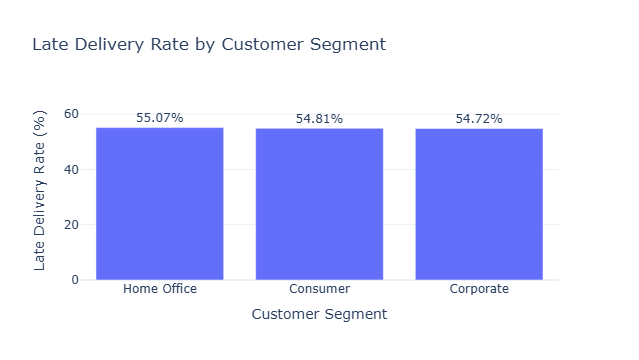

In [25]:
# ===== DELIVERY RISK BY CUSTOMER SEGMENT CHART =====

fig = px.bar(
    segment_risk,
    x="Customer Segment",
    y="Late_Delivery_Rate",
    title="Late Delivery Rate by Customer Segment",
    text="Late_Delivery_Rate"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Late Delivery Rate (%)",
    template="plotly_white"
)

fig.show()

In [26]:
# ===== SHIPPING DELAY BY CUSTOMER SEGMENT =====

segment_delay = df.groupby(
    "Customer Segment"
).agg(
    Avg_Actual_Shipping=("Days for shipping (real)", "mean"),
    Avg_Scheduled_Shipping=("Days for shipment (scheduled)", "mean")
).reset_index()

segment_delay["Shipping_Delay"] = (
    segment_delay["Avg_Actual_Shipping"]
    - segment_delay["Avg_Scheduled_Shipping"]
)

segment_delay = segment_delay.sort_values(
    "Shipping_Delay",
    ascending=False
)

print("===== SHIPPING DELAY BY CUSTOMER SEGMENT =====")
print(segment_delay)

===== SHIPPING DELAY BY CUSTOMER SEGMENT =====
  Customer Segment  Avg_Actual_Shipping  Avg_Scheduled_Shipping  \
2      Home Office             3.511450                2.933501   
0         Consumer             3.497508                2.932591   
1        Corporate             3.489788                2.929603   

   Shipping_Delay  
2        0.577949  
0        0.564917  
1        0.560185  


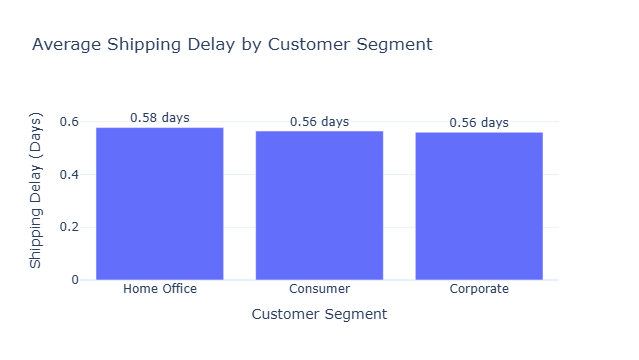

In [27]:
# ===== SHIPPING DELAY BY CUSTOMER SEGMENT CHART =====

fig = px.bar(
    segment_delay,
    x="Customer Segment",
    y="Shipping_Delay",
    title="Average Shipping Delay by Customer Segment",
    text="Shipping_Delay"
)

fig.update_traces(
    texttemplate="%{text:.2f} days",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Shipping Delay (Days)",
    template="plotly_white"
)

fig.show()

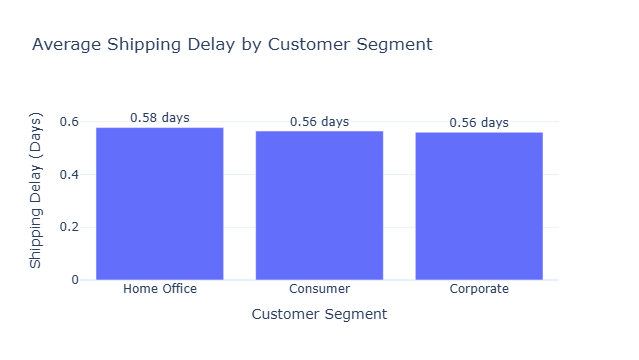

In [28]:
# ===== SHIPPING DELAY BY CUSTOMER SEGMENT CHART =====

fig = px.bar(
    segment_delay,
    x="Customer Segment",
    y="Shipping_Delay",
    title="Average Shipping Delay by Customer Segment",
    text="Shipping_Delay"
)

fig.update_traces(
    texttemplate="%{text:.2f} days",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Shipping Delay (Days)",
    template="plotly_white"
)

fig.show()

In [29]:
# ===== MONTHLY ORDER VOLUME =====

# Convert order date to datetime
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

monthly_orders = df.groupby(
    df["order date (DateOrders)"].dt.to_period("M")
).agg(
    Order_Items=("Order Item Id", "count"),
    Unique_Orders=("Order Id", "nunique")
).reset_index()

monthly_orders["order date (DateOrders)"] = (
    monthly_orders["order date (DateOrders)"]
    .astype(str)
)

print("===== MONTHLY ORDER VOLUME =====")
print(monthly_orders.head(12))

===== MONTHLY ORDER VOLUME =====
   order date (DateOrders)  Order_Items  Unique_Orders
0                  2015-01         5322           1787
1                  2015-02         4729           1585
2                  2015-03         5362           1781
3                  2015-04         5126           1710
4                  2015-05         5357           1776
5                  2015-06         5134           1725
6                  2015-07         5299           1763
7                  2015-08         5273           1762
8                  2015-09         5140           1706
9                  2015-10         5302           1775
10                 2015-11         5235           1729
11                 2015-12         5371           1805


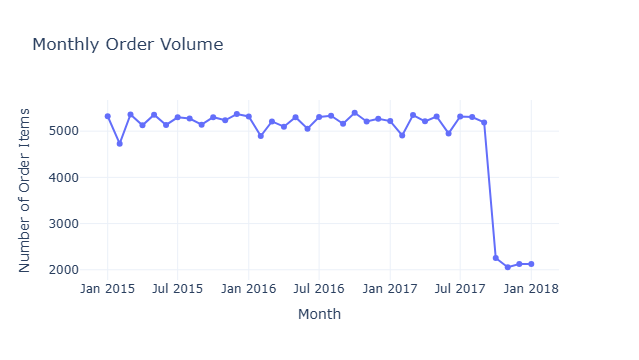

In [30]:
# ===== MONTHLY ORDER VOLUME CHART =====

fig = px.line(
    monthly_orders,
    x="order date (DateOrders)",
    y="Order_Items",
    title="Monthly Order Volume",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Order Items",
    template="plotly_white"
)

fig.show()

In [1]:
import pandas as pd
import plotly.express as px

file_path = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [2]:
# ===== STEP 94: FINAL ANALYTICAL DATASET =====

final_columns = [
    "Order Id",
    "Order Item Id",
    "order date (DateOrders)",
    "Sales",
    "Order Profit Per Order",
    "Order Item Quantity",
    "Customer Segment",
    "Market",
    "Shipping Mode",
    "Delivery Status",
    "Order Status",
    "Category Name",
    "Product Name",
    "Customer Country",
    "Order Country",
    "Order Region",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Late_delivery_risk"
]

final_df = df[final_columns].copy()

print("===== FINAL ANALYTICAL DATASET =====")
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])

print("\n===== FIRST 5 ROWS =====")
print(final_df.head())

===== FINAL ANALYTICAL DATASET =====
Rows: 180519
Columns: 19

===== FIRST 5 ROWS =====
   Order Id  Order Item Id order date (DateOrders)   Sales  \
0     77202         180517         1/31/2018 22:56  327.75   
1     75939         179254         1/13/2018 12:27  327.75   
2     75938         179253         1/13/2018 12:06  327.75   
3     75937         179252         1/13/2018 11:45  327.75   
4     75936         179251         1/13/2018 11:24  327.75   

   Order Profit Per Order  Order Item Quantity Customer Segment        Market  \
0               91.250000                    1         Consumer  Pacific Asia   
1             -249.089996                    1         Consumer  Pacific Asia   
2             -247.779999                    1         Consumer  Pacific Asia   
3               22.860001                    1      Home Office  Pacific Asia   
4              134.210007                    1        Corporate  Pacific Asia   

    Shipping Mode   Delivery Status     Order Status

In [3]:
# ===== STEP 95: FINAL KPI SUMMARY =====

total_orders = final_df["Order Id"].nunique()
total_order_items = final_df["Order Item Id"].nunique()
total_sales = final_df["Sales"].sum()
total_profit = final_df["Order Profit Per Order"].sum()
total_quantity = final_df["Order Item Quantity"].sum()

late_delivery_rate = (
    final_df["Late_delivery_risk"].mean() * 100
)

avg_actual_shipping = final_df[
    "Days for shipping (real)"
].mean()

avg_scheduled_shipping = final_df[
    "Days for shipment (scheduled)"
].mean()

profit_margin = (
    total_profit / total_sales * 100
)

print("========== FINAL KPI SUMMARY ==========")
print(f"Total Orders: {total_orders:,}")
print(f"Total Order Items: {total_order_items:,}")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")
print(f"Average Actual Shipping: {avg_actual_shipping:.2f} days")
print(f"Average Scheduled Shipping: {avg_scheduled_shipping:.2f} days")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

========== FINAL KPI SUMMARY ==========
Total Orders: 65,752
Total Order Items: 180,519
Total Sales: $36,784,735.01
Total Profit: $3,966,902.97
Total Quantity Sold: 384,079
Late Delivery Rate: 54.83%
Average Actual Shipping: 3.50 days
Average Scheduled Shipping: 2.93 days
Overall Profit Margin: 10.78%


In [4]:
# ===== STEP 96: SAVE FINAL ANALYTICAL DATASET =====

output_file = "../data/processed/final_analytical_dataset.csv"

final_df.to_csv(
    output_file,
    index=False
)

print("Final analytical dataset saved successfully!")
print("File:", output_file)
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [5]:
import os

os.makedirs("../data/processed", exist_ok=True)

print("Processed folder is ready!")

Processed folder is ready!


In [6]:
import os

os.makedirs("../data/processed", exist_ok=True)

print("Processed folder is ready!")

Processed folder is ready!


In [7]:
# ===== STEP 96: SAVE FINAL ANALYTICAL DATASET =====

output_file = "../data/processed/final_analytical_dataset.csv"

final_df.to_csv(
    output_file,
    index=False
)

print("Final analytical dataset saved successfully!")
print("File:", output_file)
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])

Final analytical dataset saved successfully!
File: ../data/processed/final_analytical_dataset.csv
Rows: 180519
Columns: 19


In [8]:
# ===== STEP 97: BUSINESS INSIGHTS =====

print("========== KEY BUSINESS INSIGHTS ==========\n")

print("1. DELIVERY PERFORMANCE")
print("• Overall late delivery rate: 54.83%")
print("• Average actual shipping time: 3.50 days")
print("• Average scheduled shipping time: 2.93 days")
print("• Actual shipping takes about 0.57 days longer than scheduled.\n")

print("2. SHIPPING MODE")
print("• First Class has the highest late delivery rate: 95.32%")
print("• Second Class has a late delivery rate of 76.63%")
print("• Standard Class has the lowest late delivery rate: 38.07%\n")

print("3. SALES PERFORMANCE")
print("• Total sales: $36.78 million")
print("• Total profit: $3.97 million")
print("• Overall profit margin: 10.78%")
print("• 2015 was the strongest complete year by sales.\n")

print("4. MARKET PERFORMANCE")
print("• Europe generated the highest sales: $10.87 million")
print("• LATAM generated about $10.28 million in sales.")
print("• USCA achieved the highest market profit margin: 11.14%.\n")

print("5. CUSTOMER SEGMENTS")
print("• Consumer customers generated the highest sales: $19.10 million")
print("• Corporate customers generated $11.17 million.")
print("• Home Office customers generated $6.52 million.\n")

print("6. PRODUCT PERFORMANCE")
print("• Fishing was the highest-sales product category.")
print("• The Field & Stream Sportsman 16 Gun Fire Safe was the highest-sales product.")
print("• Golf Bags & Carts had the highest category profit margin: 17.46%.\n")

print("7. DISCOUNT IMPACT")
print("• Higher discount rates generally correspond with lower profit.")
print("• Sales remained relatively similar across the analyzed discount rates.")
print("• This suggests discounts should be managed carefully to protect profitability.\n")

print("8. OVERALL BUSINESS PRIORITY")
print("• The biggest operational issue is late delivery.")
print("• Improving delivery performance could significantly improve customer satisfaction.")
print("• Shipping mode and regional delivery performance should be monitored closely.")

========== KEY BUSINESS INSIGHTS ==========

1. DELIVERY PERFORMANCE
• Overall late delivery rate: 54.83%
• Average actual shipping time: 3.50 days
• Average scheduled shipping time: 2.93 days
• Actual shipping takes about 0.57 days longer than scheduled.

2. SHIPPING MODE
• First Class has the highest late delivery rate: 95.32%
• Second Class has a late delivery rate of 76.63%
• Standard Class has the lowest late delivery rate: 38.07%

3. SALES PERFORMANCE
• Total sales: $36.78 million
• Total profit: $3.97 million
• Overall profit margin: 10.78%
• 2015 was the strongest complete year by sales.

4. MARKET PERFORMANCE
• Europe generated the highest sales: $10.87 million
• LATAM generated about $10.28 million in sales.
• USCA achieved the highest market profit margin: 11.14%.

5. CUSTOMER SEGMENTS
• Consumer customers generated the highest sales: $19.10 million
• Corporate customers generated $11.17 million.
• Home Office customers generated $6.52 million.

6. PRODUCT PERFORMANCE
• Fish

In [9]:
# ===== STEP 98: BUSINESS RECOMMENDATIONS =====

print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("1. IMPROVE DELIVERY PERFORMANCE")
print("• Investigate the causes of the 54.83% late delivery rate.")
print("• Review warehouse processing, transportation, and carrier performance.")
print("• Set operational targets to reduce late deliveries.\n")

print("2. REVIEW SHIPPING MODES")
print("• First Class has a very high late delivery rate of 95.32%.")
print("• Analyze whether First Class delivery promises are realistic.")
print("• Review carrier performance and shipping schedules for First Class and Second Class.\n")

print("3. OPTIMIZE INVENTORY AND OPERATIONS")
print("• Focus inventory planning on high-sales product categories.")
print("• Maintain sufficient stock for products with consistently high demand.")
print("• Use historical sales patterns to improve demand forecasting.\n")

print("4. FOCUS ON HIGH-VALUE MARKETS")
print("• Europe is the largest market by sales.")
print("• LATAM is also a major contributor to sales.")
print("• Prioritize resources and operational improvements in high-performing markets.\n")

print("5. STRENGTHEN CUSTOMER SEGMENT STRATEGY")
print("• Consumer customers generate the highest sales.")
print("• Develop targeted offers and retention strategies for Consumer customers.")
print("• Continue analyzing Corporate and Home Office segments for growth opportunities.\n")

print("6. MANAGE DISCOUNTS CAREFULLY")
print("• Higher discounts are generally associated with lower profit.")
print("• Avoid unnecessary discounts when sales demand is already strong.")
print("• Use targeted promotions instead of broad discounting.\n")

print("7. MONITOR PROFITABILITY")
print("• Track profit margin by product, market, customer segment, and shipping mode.")
print("• Give additional attention to high-margin categories such as Golf Bags & Carts.")
print("• Identify low-margin categories that may require pricing or cost optimization.\n")

print("8. BUILD A MANAGEMENT DASHBOARD")
print("• Track sales, profit, orders, quantity, and delivery performance.")
print("• Include filters for market, customer segment, product category, and shipping mode.")
print("• Use the dashboard for regular operational decision-making.")

========== BUSINESS RECOMMENDATIONS ==========

1. IMPROVE DELIVERY PERFORMANCE
• Investigate the causes of the 54.83% late delivery rate.
• Review warehouse processing, transportation, and carrier performance.
• Set operational targets to reduce late deliveries.

2. REVIEW SHIPPING MODES
• First Class has a very high late delivery rate of 95.32%.
• Analyze whether First Class delivery promises are realistic.
• Review carrier performance and shipping schedules for First Class and Second Class.

3. OPTIMIZE INVENTORY AND OPERATIONS
• Focus inventory planning on high-sales product categories.
• Maintain sufficient stock for products with consistently high demand.
• Use historical sales patterns to improve demand forecasting.

4. FOCUS ON HIGH-VALUE MARKETS
• Europe is the largest market by sales.
• LATAM is also a major contributor to sales.
• Prioritize resources and operational improvements in high-performing markets.

5. STRENGTHEN CUSTOMER SEGMENT STRATEGY
• Consumer customers genera

In [10]:
# ===== STEP 99: CREATE PROJECT DOCUMENTATION =====

documentation = """
SUPPLY CHAIN & LOGISTICS ANALYTICS PROJECT
===========================================

1. PROJECT TITLE
----------------
Supply Chain & Logistics Analytics using Python

2. PROBLEM STATEMENT
--------------------
The objective of this project is to analyze supply chain and logistics
data to understand sales performance, profitability, customer behavior,
product performance, shipping efficiency, and delivery risks.

3. PROJECT OBJECTIVES
---------------------
• Analyze sales and profit performance.
• Identify high-performing products and categories.
• Analyze customer segments and markets.
• Evaluate shipping modes and delivery performance.
• Identify late-delivery risks.
• Analyze the relationship between discounts and profitability.
• Generate actionable business insights and recommendations.

4. DATASET
----------
Dataset: DataCo Supply Chain Dataset

Records: 180,519
Columns in original dataset: 53
Final analytical columns: 19

5. TECHNOLOGIES USED
--------------------
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Plotly
• Jupyter Notebook
• Scikit-learn
• SQLAlchemy
• FastAPI

6. DATA CLEANING
----------------
• Loaded the dataset using Latin-1 encoding.
• Checked dataset dimensions and data types.
• Checked missing values.
• Checked duplicate records.
• Verified duplicate Order Item IDs.
• Converted order and shipping dates into datetime format.
• Created useful date-based features.
• Selected 19 important columns for the final analytical dataset.

7. KEY PERFORMANCE INDICATORS
-----------------------------
Total Orders: 65,752
Total Order Items: 180,519
Total Sales: $36,784,735.01
Total Profit: $3,966,902.97
Total Quantity Sold: 384,079
Late Delivery Rate: 54.83%
Average Actual Shipping: 3.50 days
Average Scheduled Shipping: 2.93 days
Overall Profit Margin: 10.78%

8. KEY BUSINESS INSIGHTS
------------------------
• Overall late delivery rate is 54.83%.
• Actual shipping takes approximately 0.57 days longer than scheduled.
• First Class has the highest late delivery rate at 95.32%.
• Standard Class has the lowest late delivery rate at 38.07%.
• Europe is the largest market by sales with approximately $10.87 million.
• Consumer customers generate the highest sales at approximately $19.10 million.
• Fishing is the highest-sales product category.
• The Field & Stream Sportsman 16 Gun Fire Safe is the highest-sales product.
• Golf Bags & Carts has the highest category profit margin at 17.46%.
• Higher discount rates generally correspond with lower profit.

9. BUSINESS RECOMMENDATIONS
---------------------------
• Investigate the causes of late deliveries.
• Review warehouse, transportation, and carrier performance.
• Review First Class and Second Class shipping performance.
• Improve inventory planning for high-demand products.
• Focus operational resources on high-performing markets.
• Develop targeted strategies for Consumer customers.
• Manage discounts carefully to protect profitability.
• Monitor profit margins across products, markets, and shipping modes.
• Build a management dashboard for continuous monitoring.

10. CONCLUSION
--------------
The analysis shows that the business generates substantial sales and
profit, but delivery performance is a major operational challenge.
More than half of the analyzed order items are associated with late
delivery risk.

Improving logistics performance, optimizing shipping modes, managing
discounts, and focusing on high-performing products and markets can
help improve operational efficiency, customer satisfaction, and
profitability.

===========================================
END OF PROJECT DOCUMENTATION
===========================================
"""

documentation_file = "../data/processed/project_documentation.txt"

with open(documentation_file, "w", encoding="utf-8") as file:
    file.write(documentation)

print("Project documentation created successfully!")
print("File:", documentation_file)

Project documentation created successfully!
File: ../data/processed/project_documentation.txt


In [11]:
# ===== STEP 100: FINAL PROJECT REVIEW =====

import os

project_files = [
    "../data/raw/DataCoSupplyChainDataset.csv",
    "../data/processed/final_analytical_dataset.csv",
    "../data/processed/project_documentation.txt",
    "../notebooks/01_data_exploration.ipynb",
    "../requirements.txt"
]

print("========== FINAL PROJECT REVIEW ==========\n")

for file_path in project_files:
    if os.path.exists(file_path):
        print("✓ Found:", file_path)
    else:
        print("✗ Missing:", file_path)

print("\n========== PROJECT SUMMARY ==========")
print("Final dataset rows:", final_df.shape[0])
print("Final dataset columns:", final_df.shape[1])
print("Project review completed!")

========== FINAL PROJECT REVIEW ==========

✓ Found: ../data/raw/DataCoSupplyChainDataset.csv
✓ Found: ../data/processed/final_analytical_dataset.csv
✓ Found: ../data/processed/project_documentation.txt
✓ Found: ../notebooks/01_data_exploration.ipynb
✓ Found: ../requirements.txt

========== PROJECT SUMMARY ==========
Final dataset rows: 180519
Final dataset columns: 19
Project review completed!
